In [1]:
import os
import joblib
import ternary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import LinearRegression

if os.path.basename(os.getcwd()) == "analysis":
    os.chdir("../")

In [2]:
data_path = "data/"
output_dir = "model"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
min_Eg=1.5
max_Eg=1.7
max_TF=1
min_TF=0.9

fontsize=12
offset = 0.14
scale = 20

select_cols=["xA", "yA", "zA", "xC", "yC", "zC", "rA", "rB", "rC", "TF"]
df = pd.read_csv(data_path+"prepared_predict_Sona.csv")[select_cols]
X_b=df[select_cols]

In [4]:
models = [
    ("Linear Regression", LinearRegression()),
    ("Random Forest Regression", RandomForestRegressor(max_depth=3, random_state=0)),### fits worse the right lower corner, and lower edge (confirm)
    ("Random Forest Regression1", RandomForestRegressor(max_depth=3, random_state=0)),
    ("Gradient Boosting Regression", GradientBoostingRegressor(random_state=0)),###in agreement with random forest
    ("Kernel Ridge Regression", KernelRidge())## ? also in agreement with random forest. check how it works
]

In [5]:
from ternary.helpers import simplex_iterator

# Generalized function for calculating Eg values
def calculate_eg(x, y, z, scale, col, dtf):
    # Scale x, y, z to match the values in the DataFrame
    eg = dtf[(dtf["x"+col] == x / scale) & 
             (dtf["y"+col] == y / scale) & 
             (dtf["z"+col] == z / scale)]["predicted"].mean()
    return eg

# Function to generate heatmap data
def generate_heatmap_data_for_r(scale, col, dtf):
    d = dict()
    for (i, j, k) in simplex_iterator(scale):
        d[(i, j, k)] = calculate_eg(i, j, k, scale, col, dtf)
    return d

/tmp/ipykernel_40243/941711659.py:20: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1,2, figsize=(15, 5))


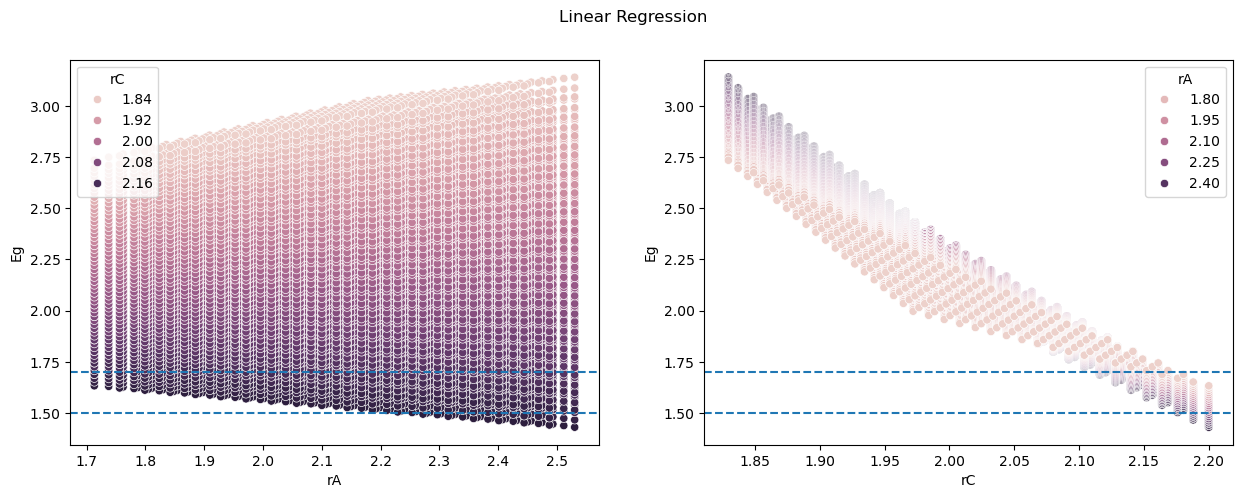

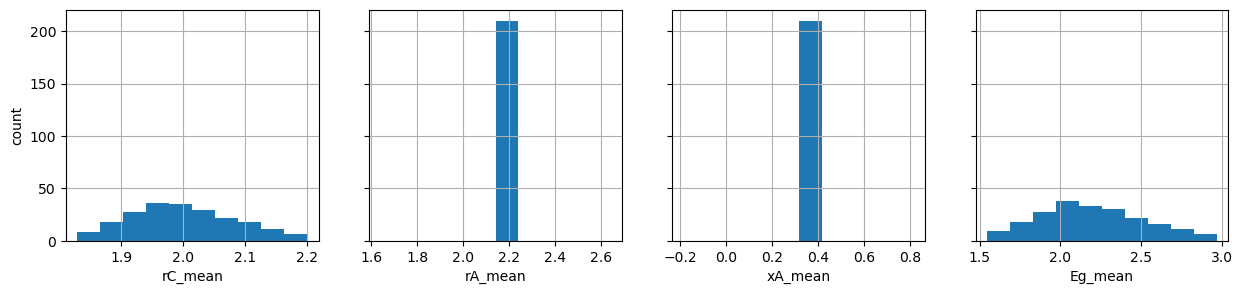

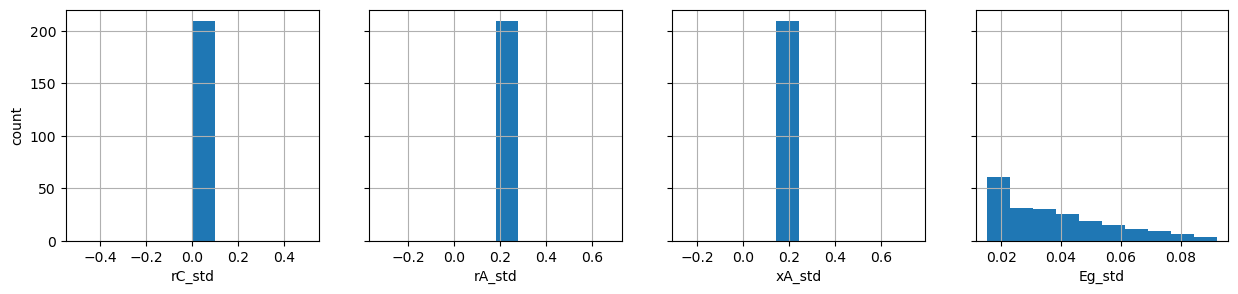

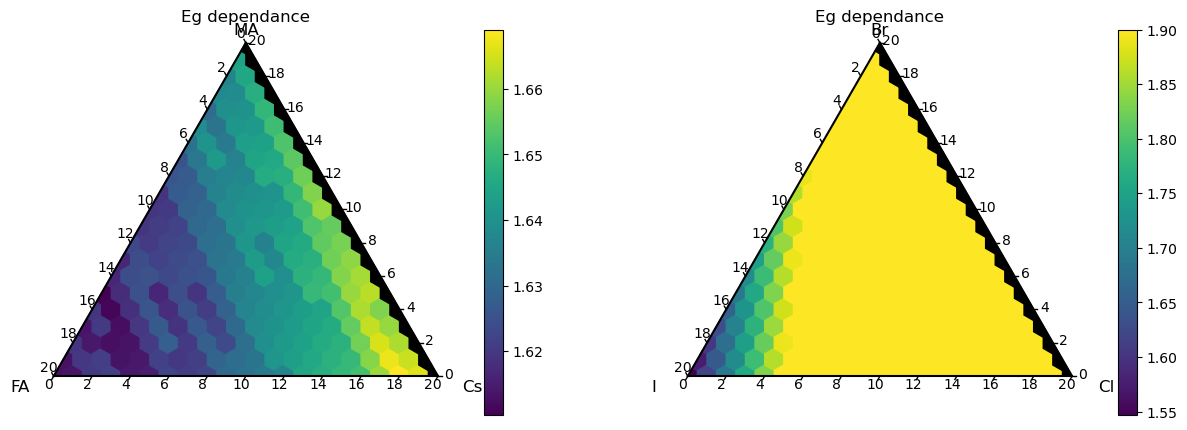

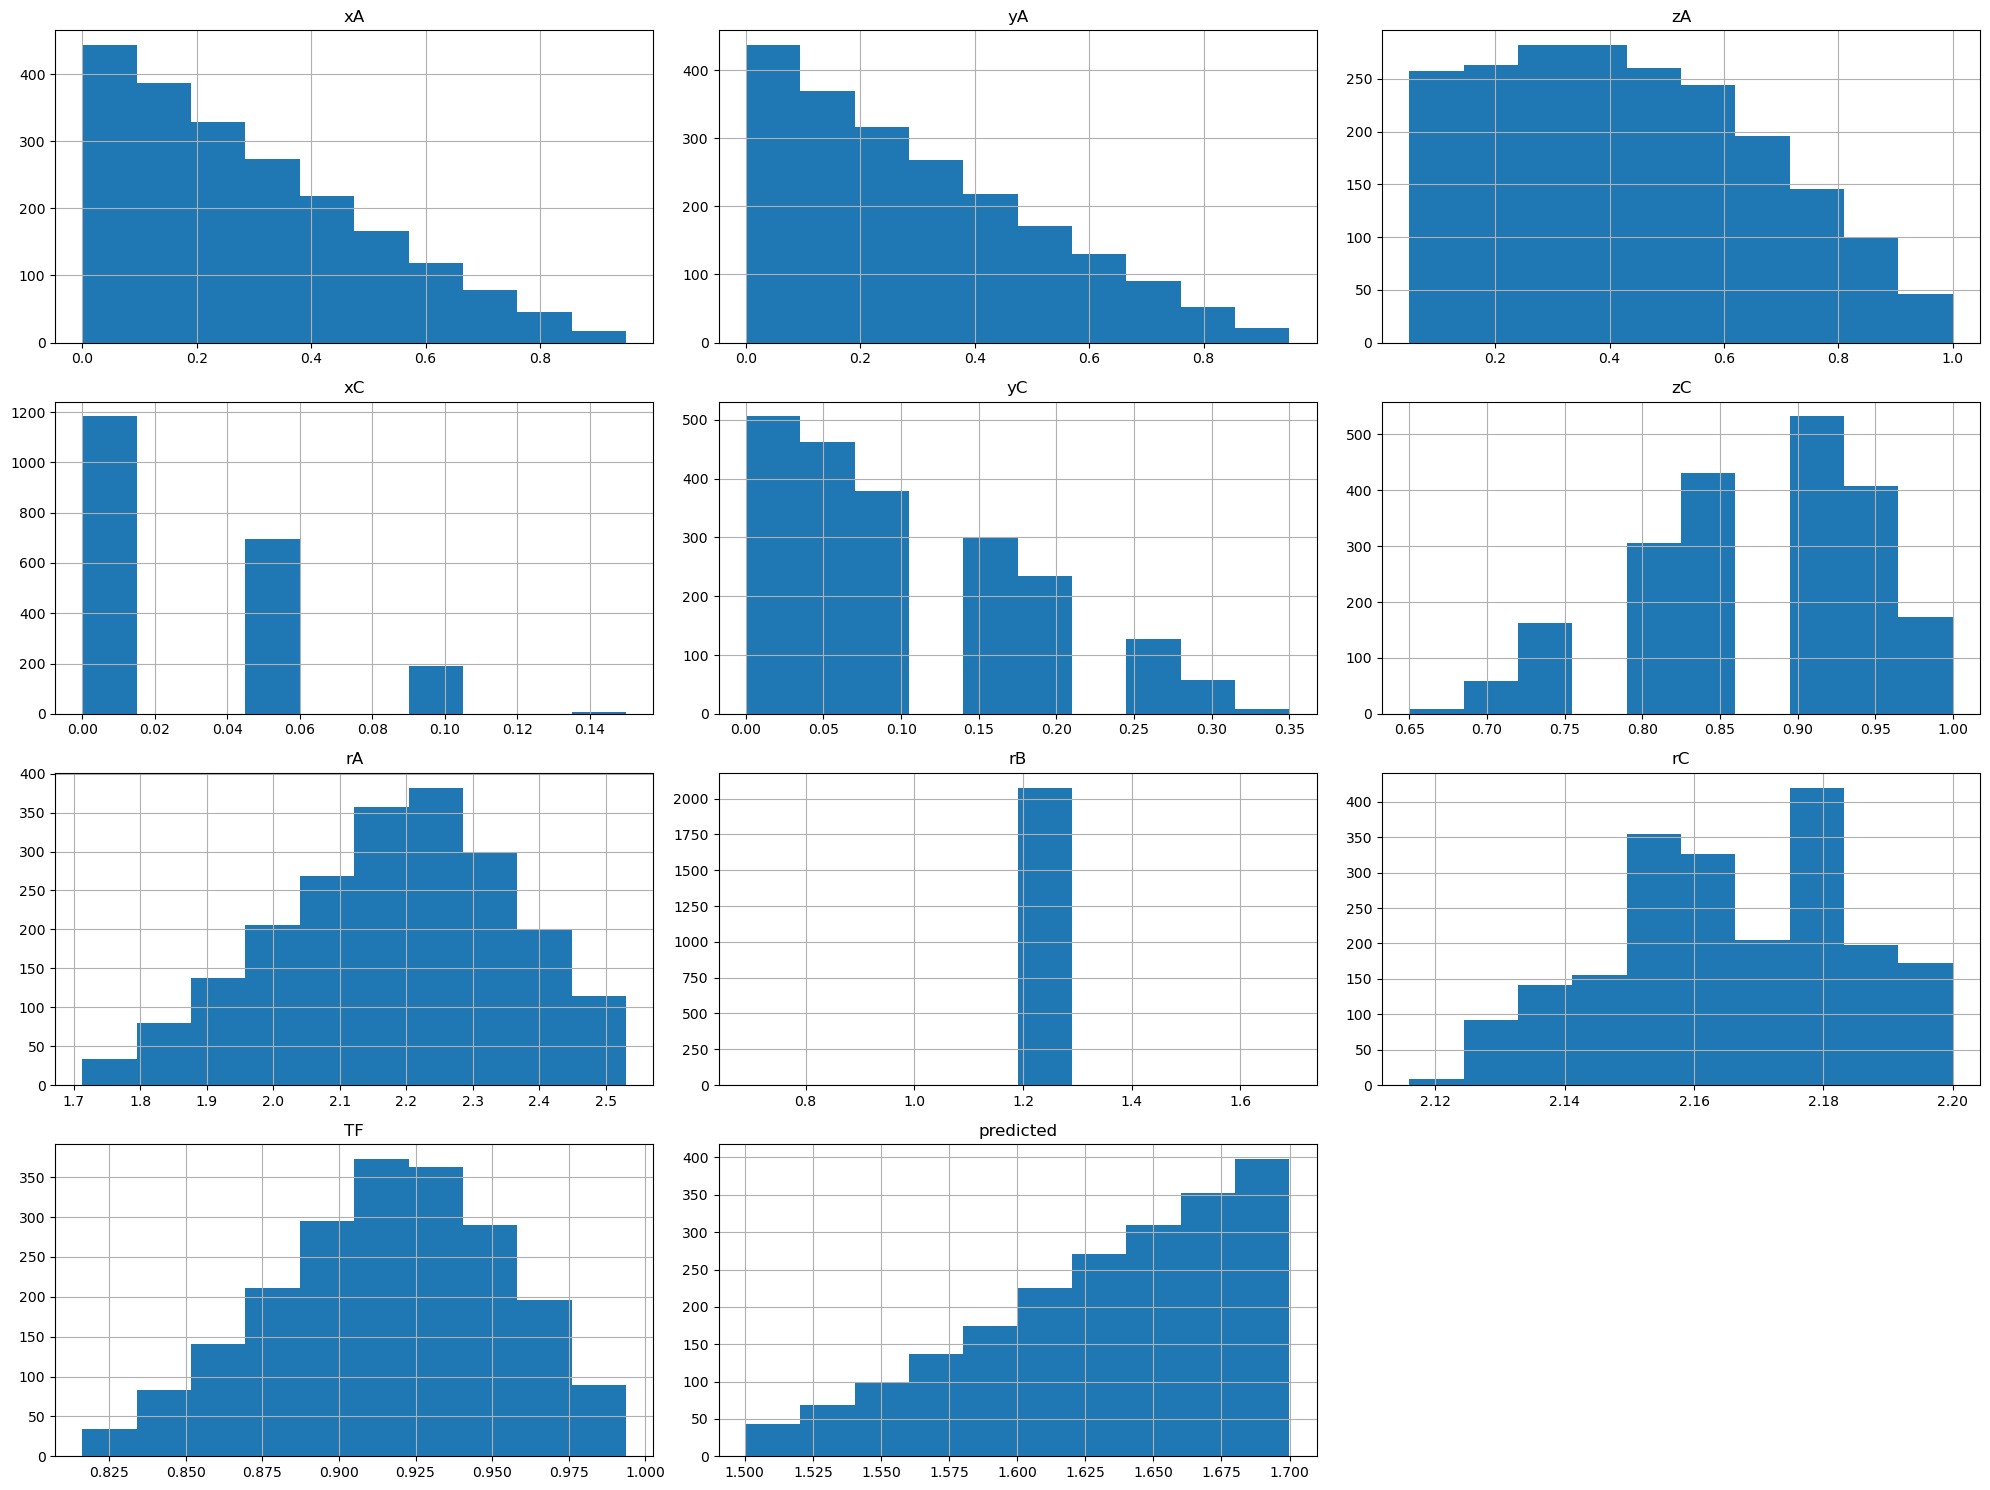

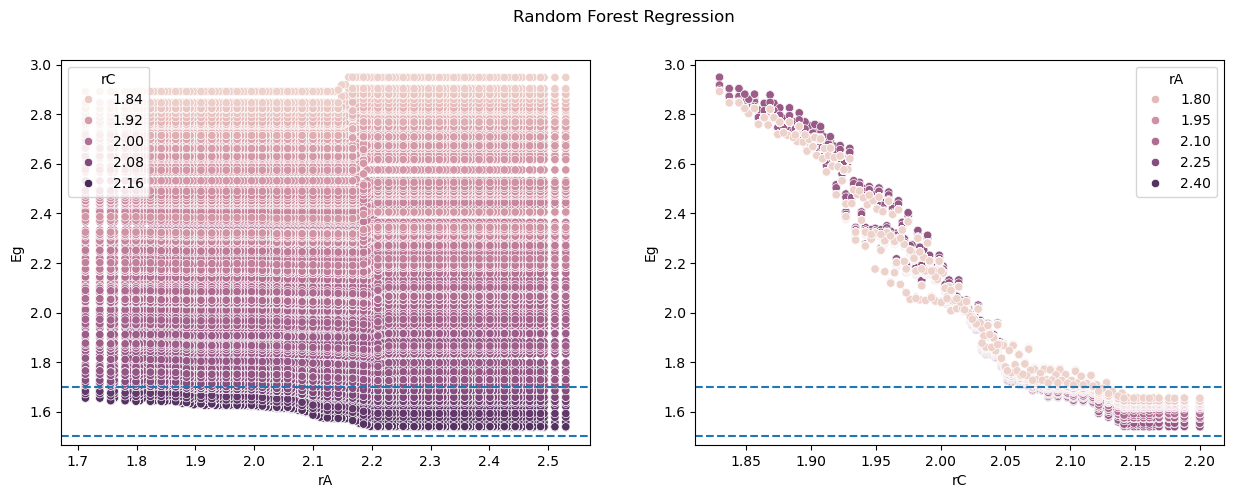

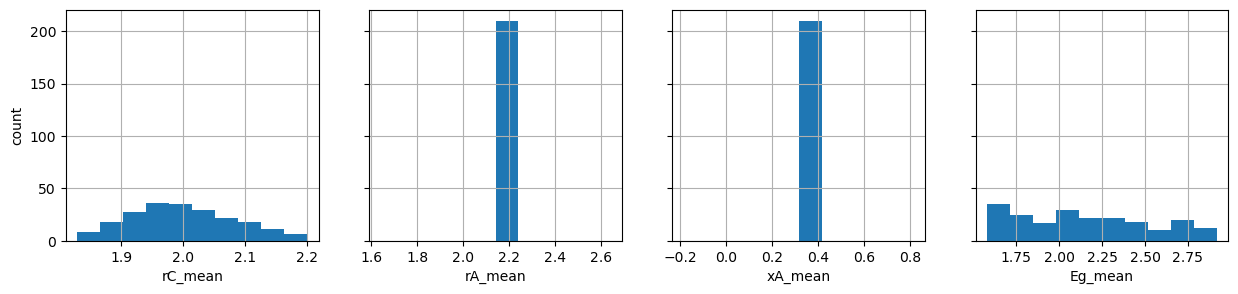

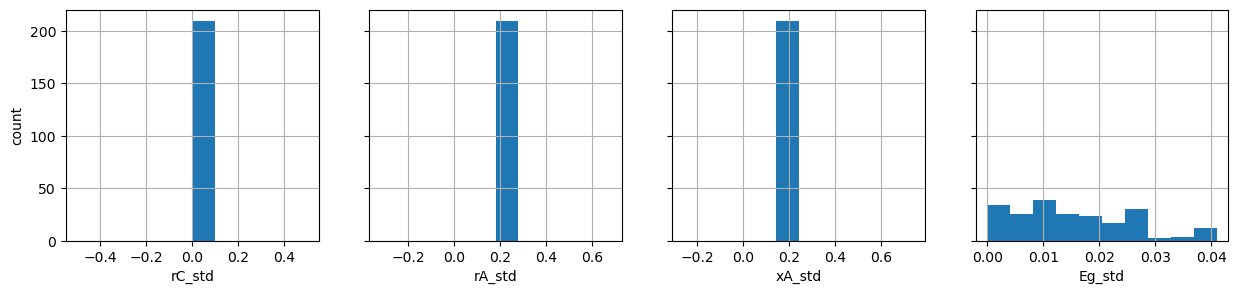

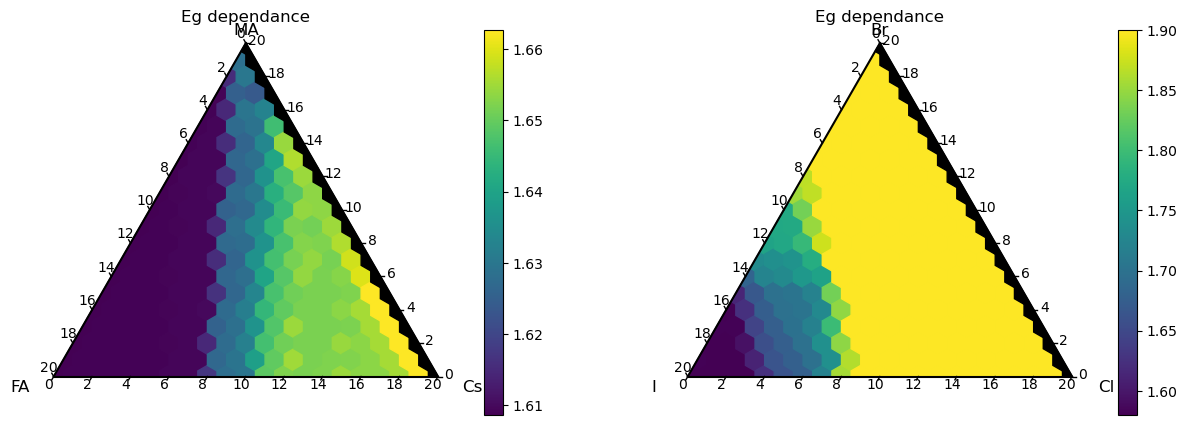

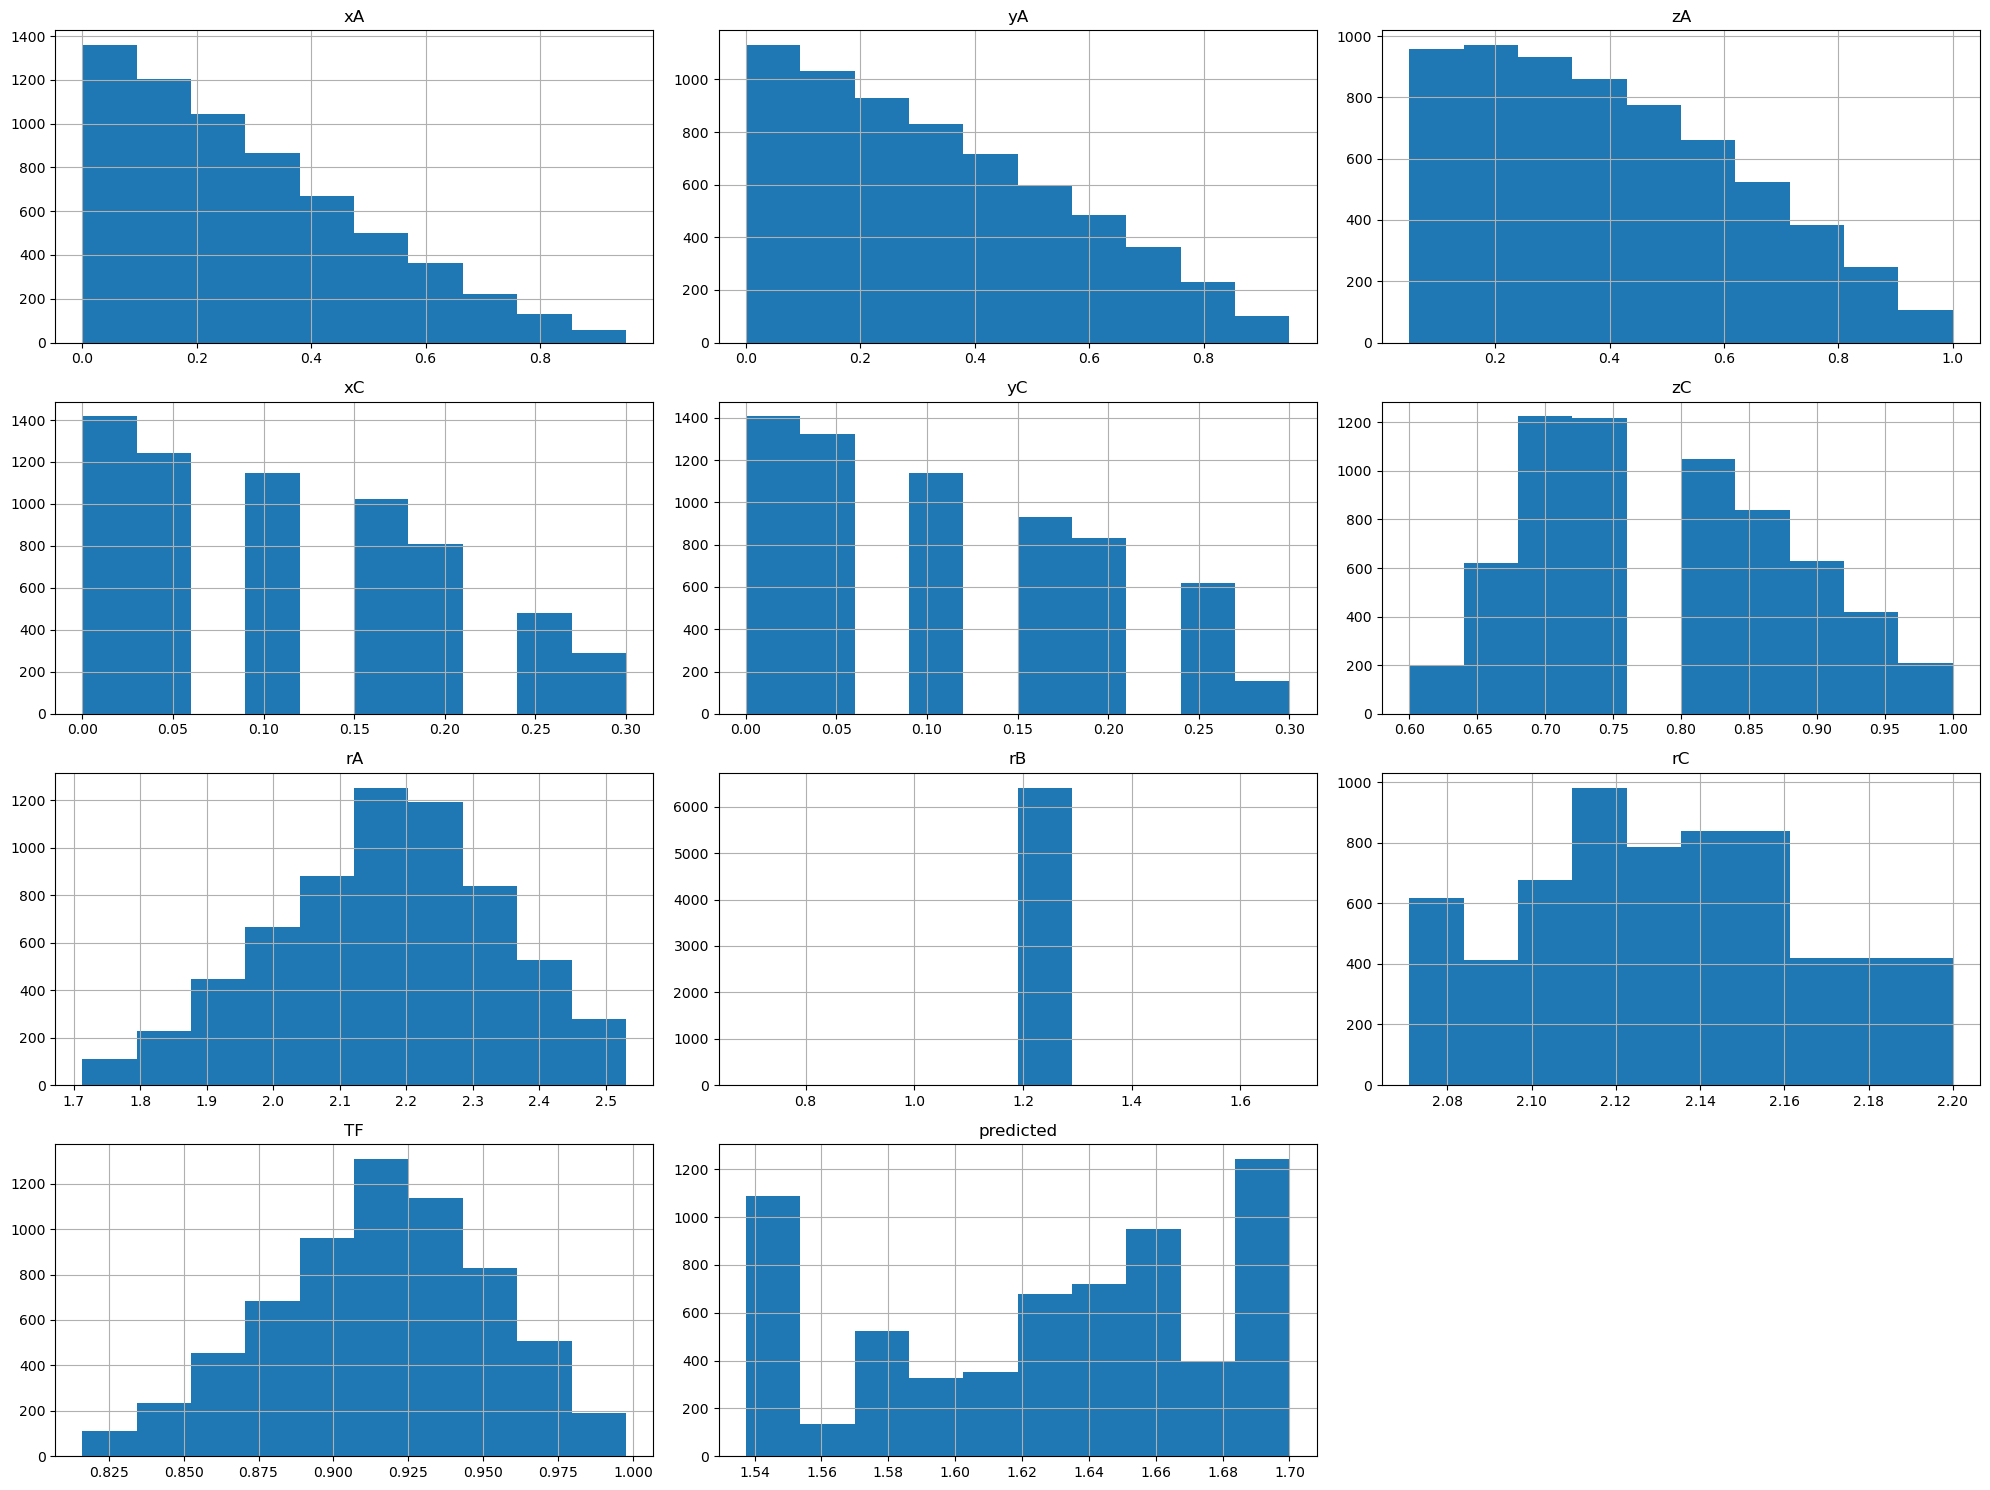

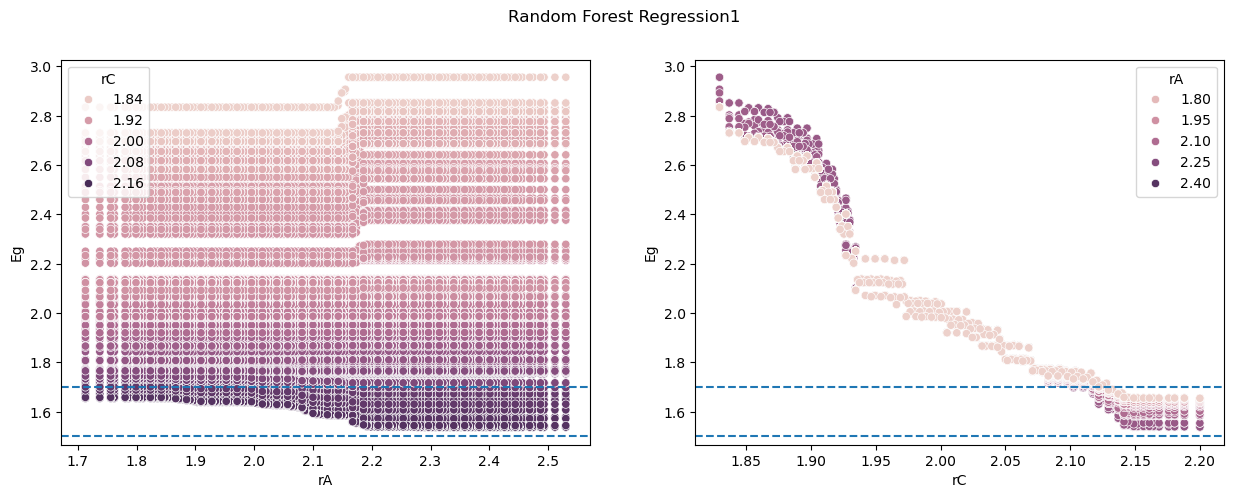

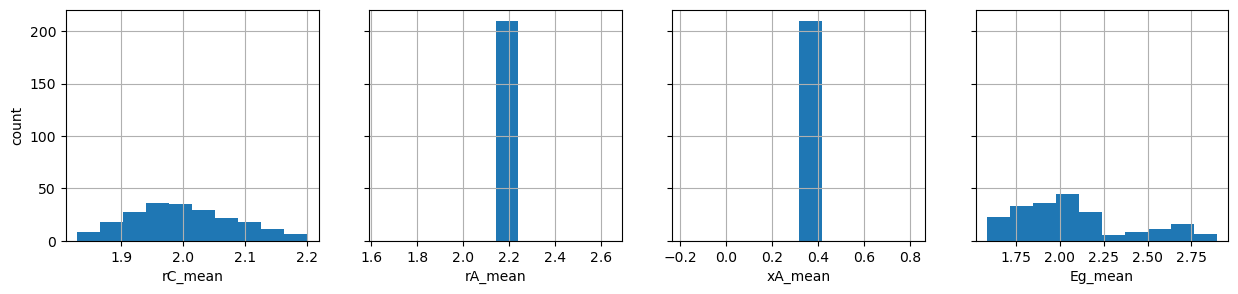

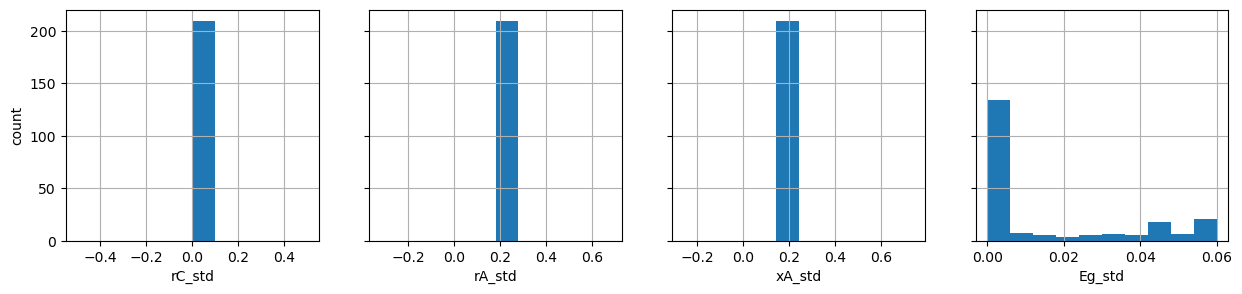

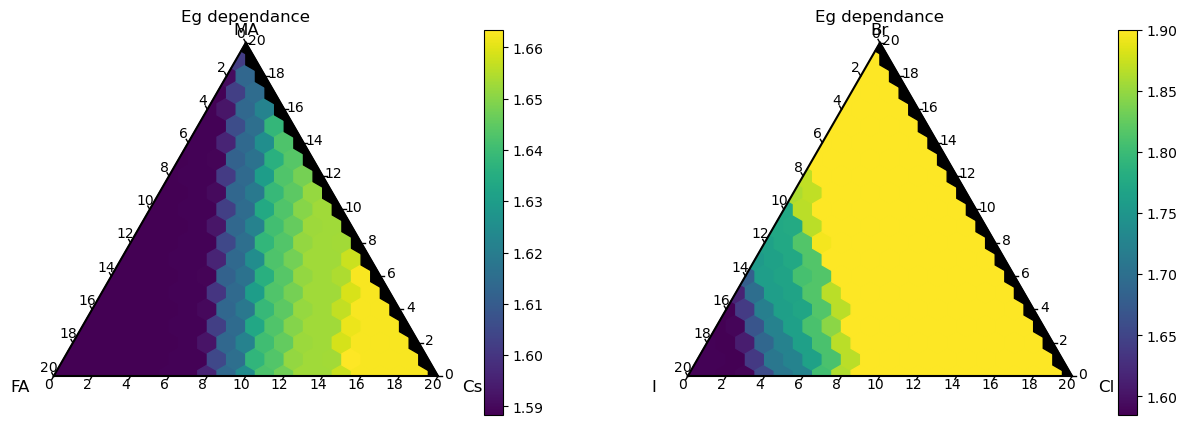

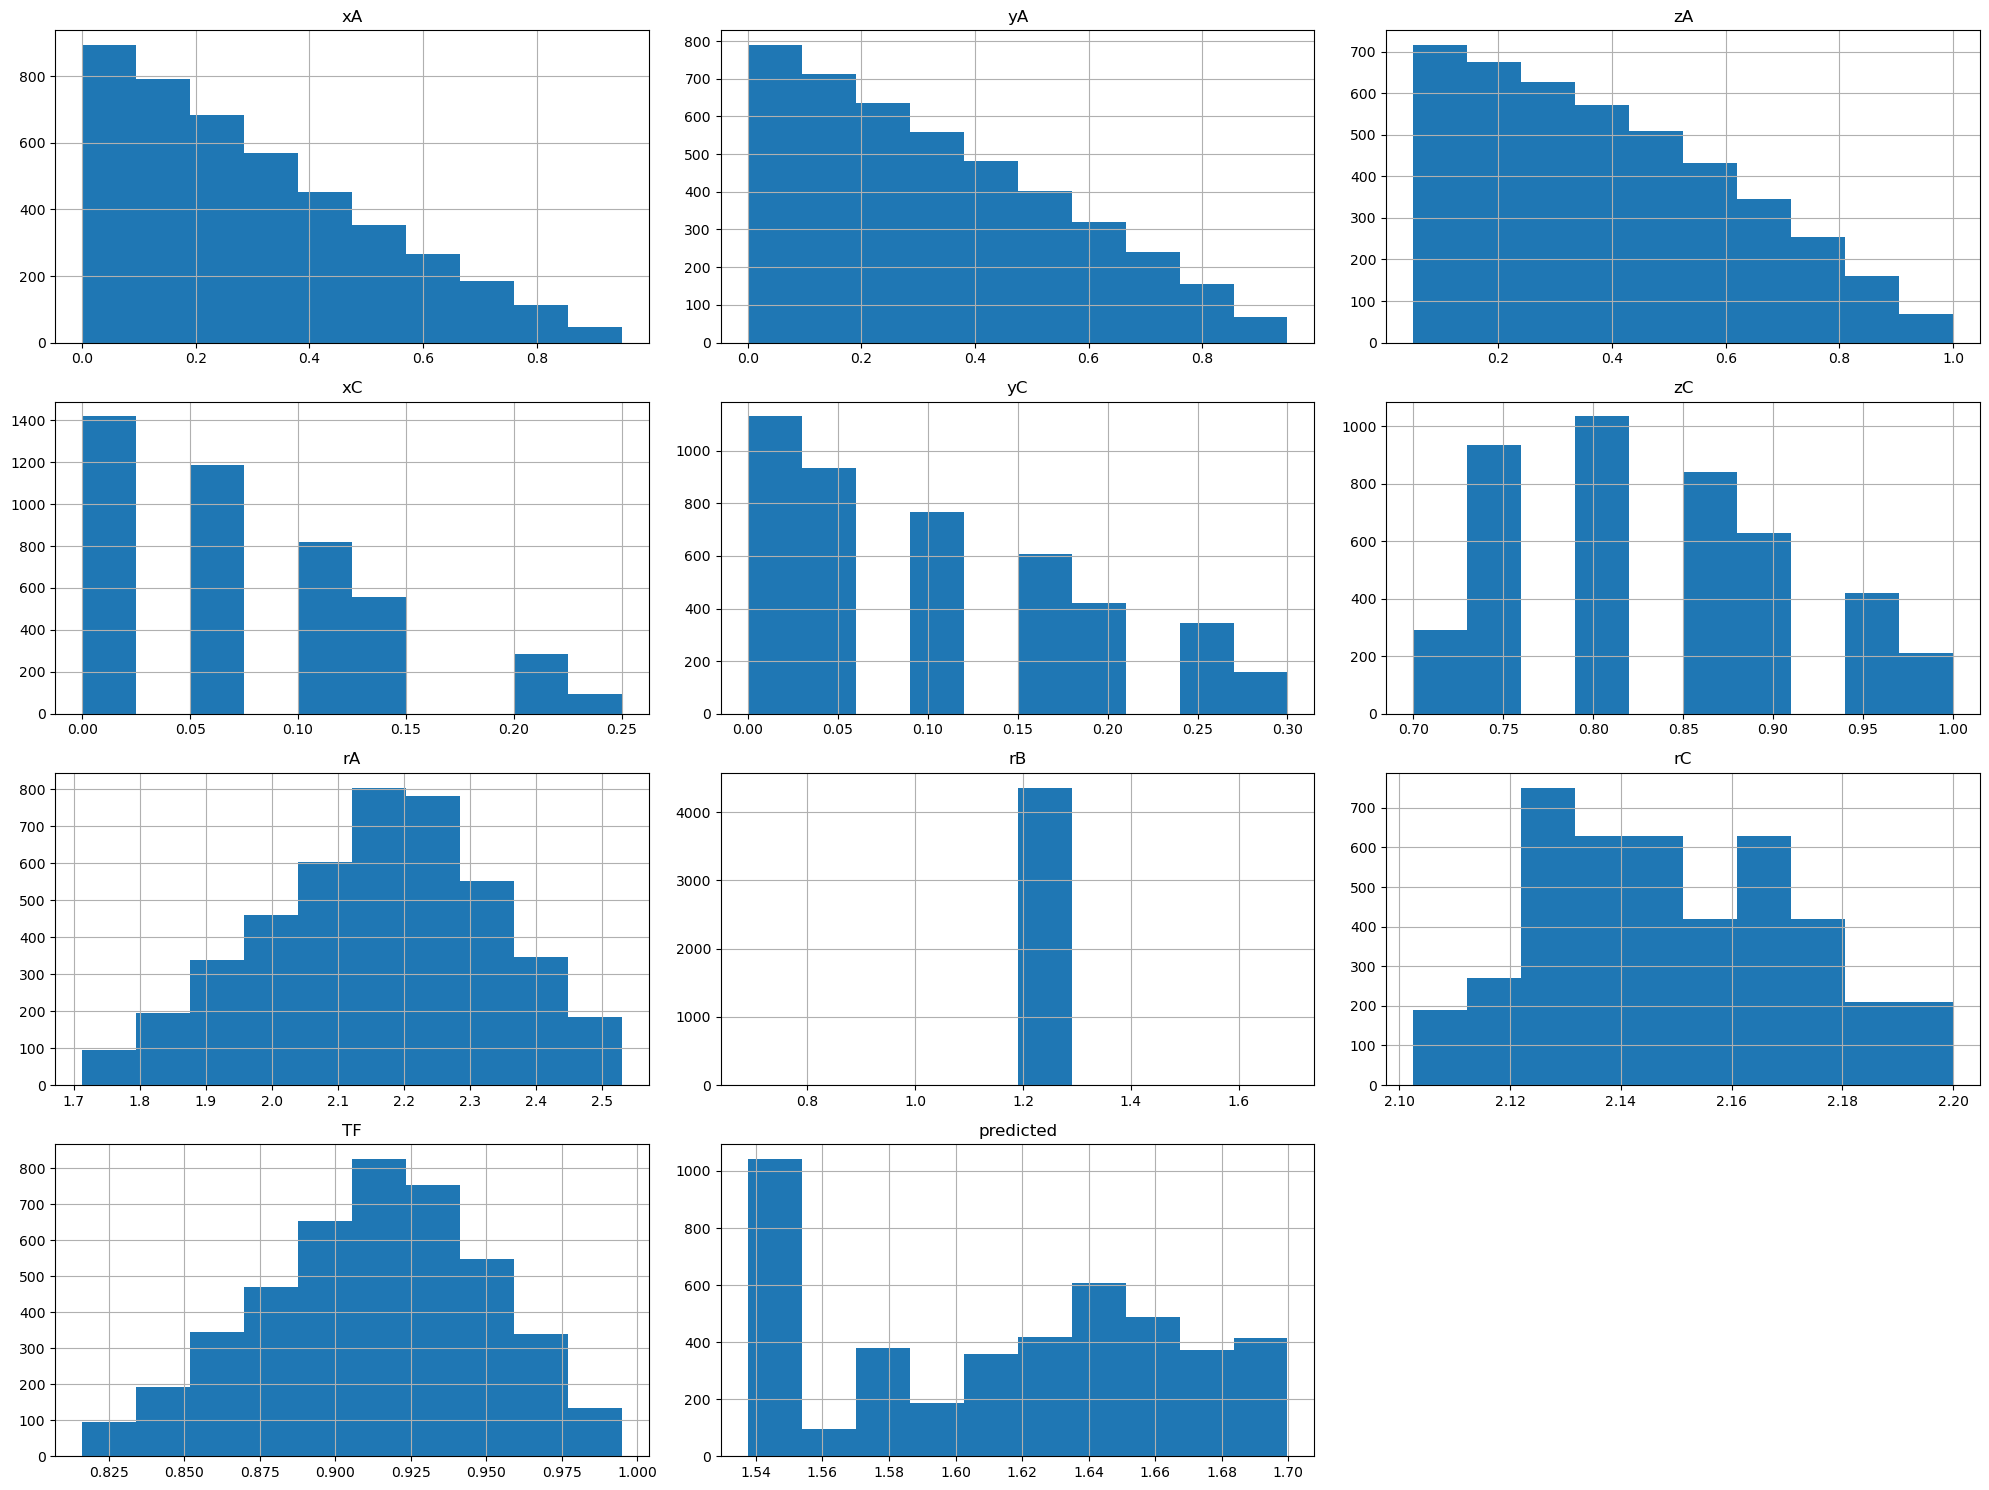

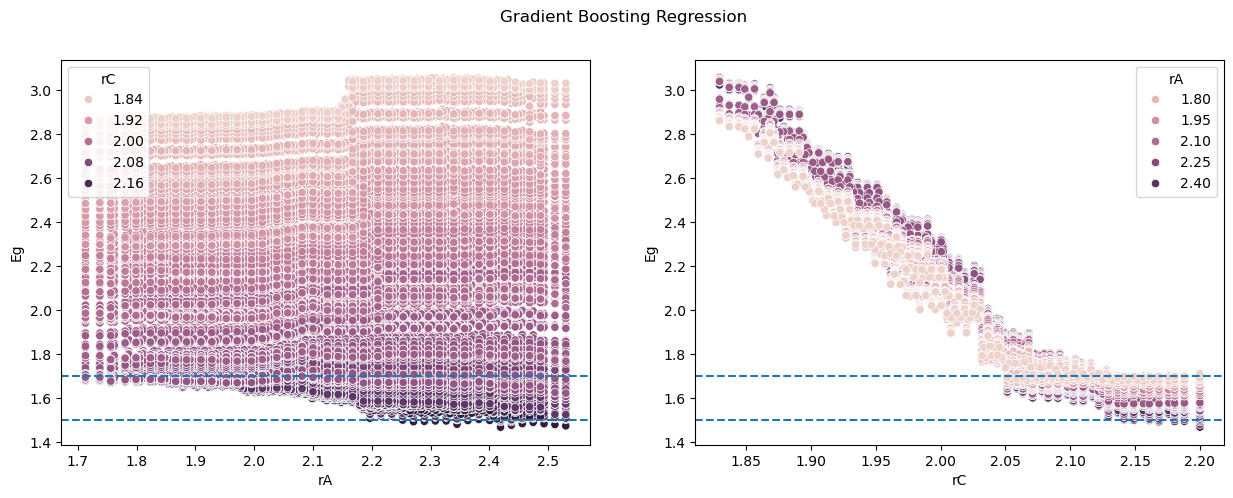

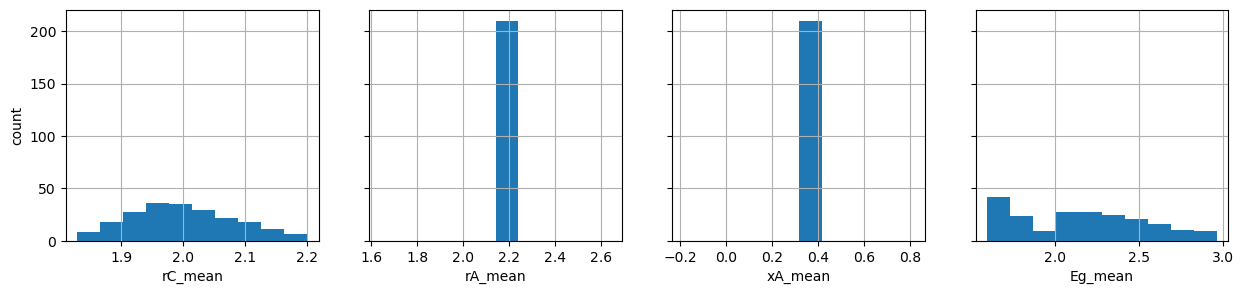

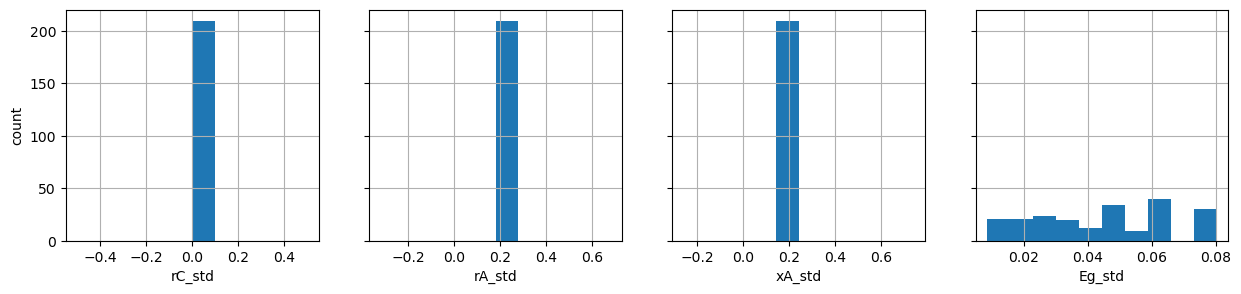

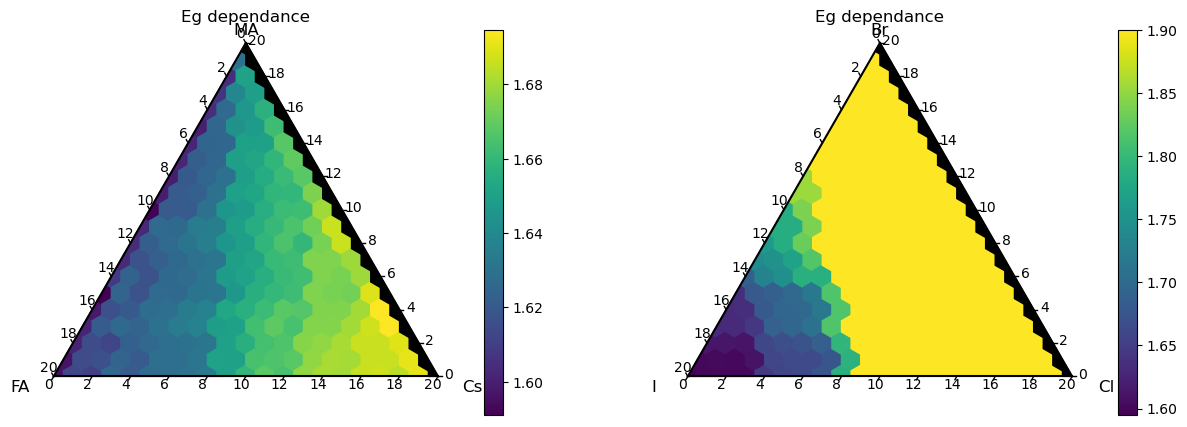

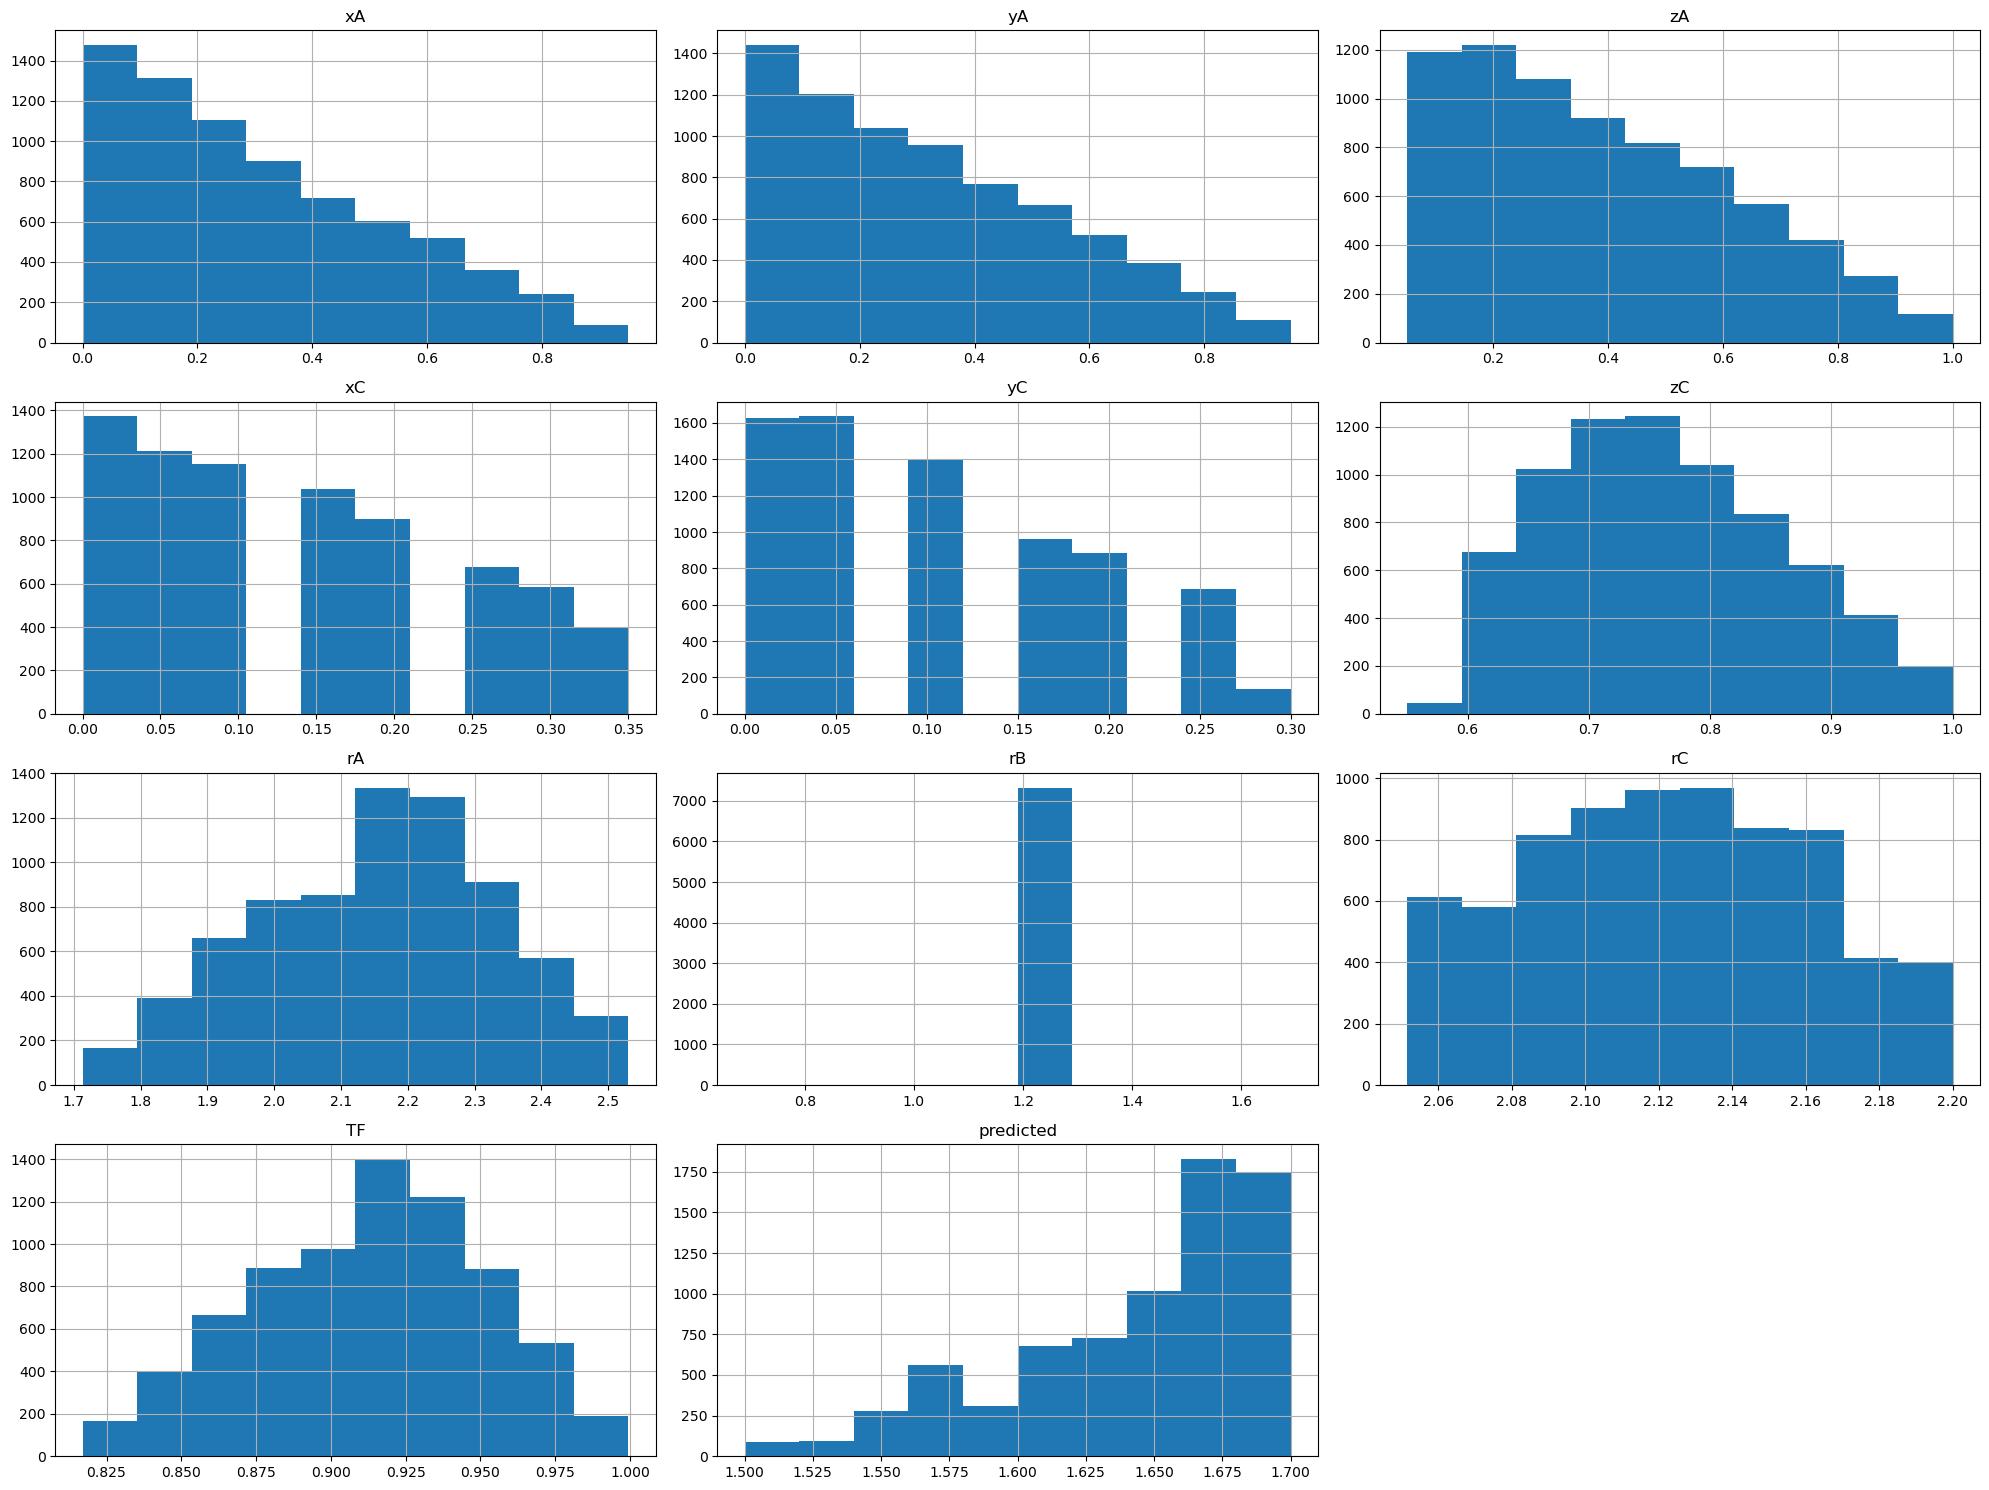

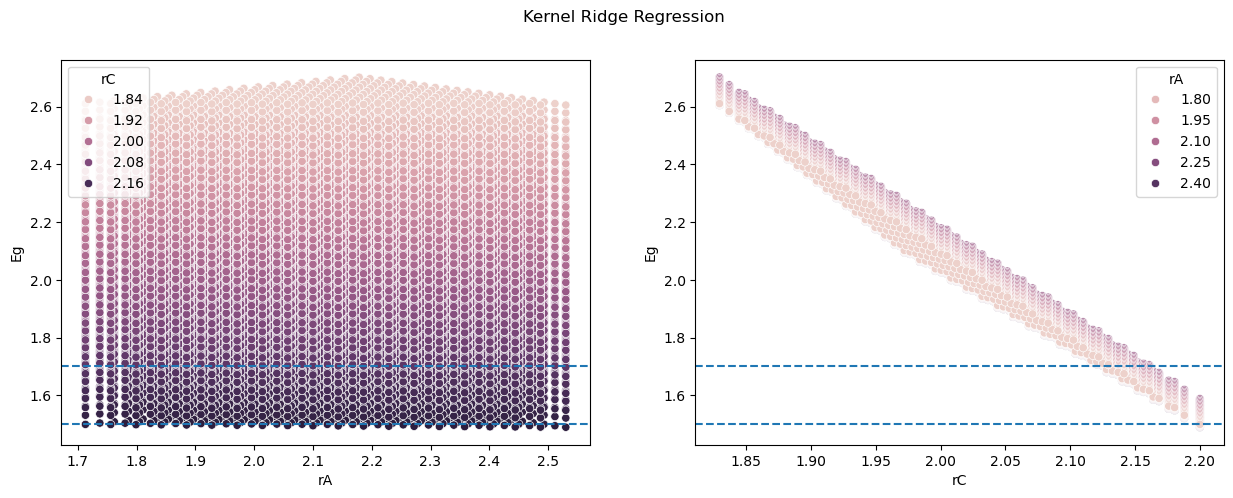

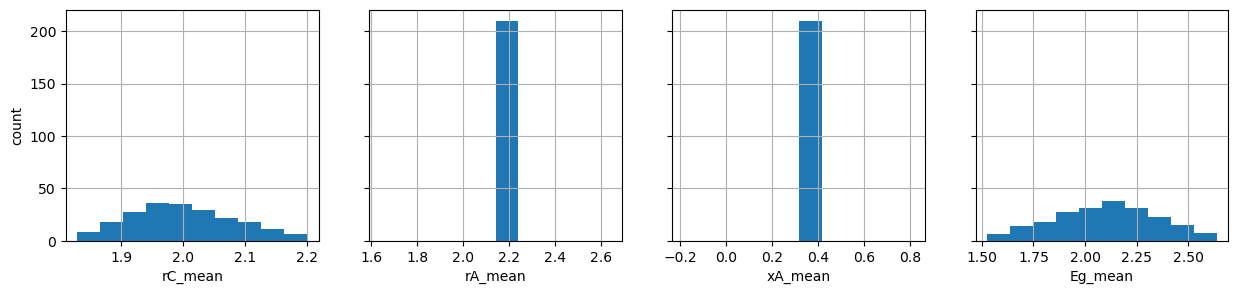

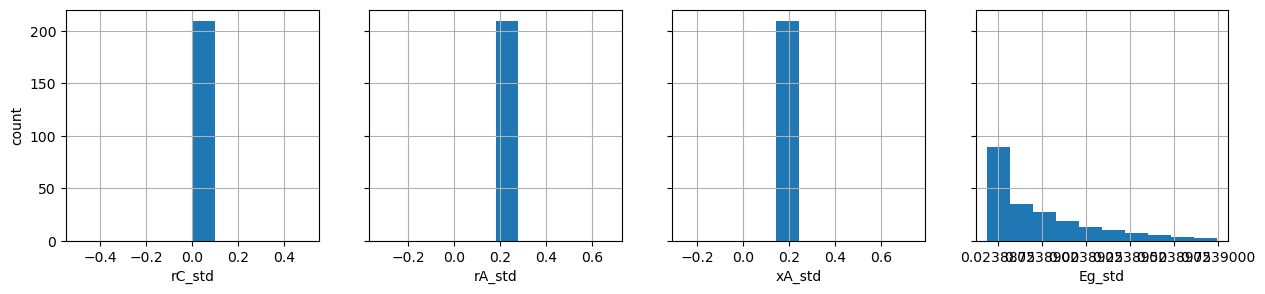

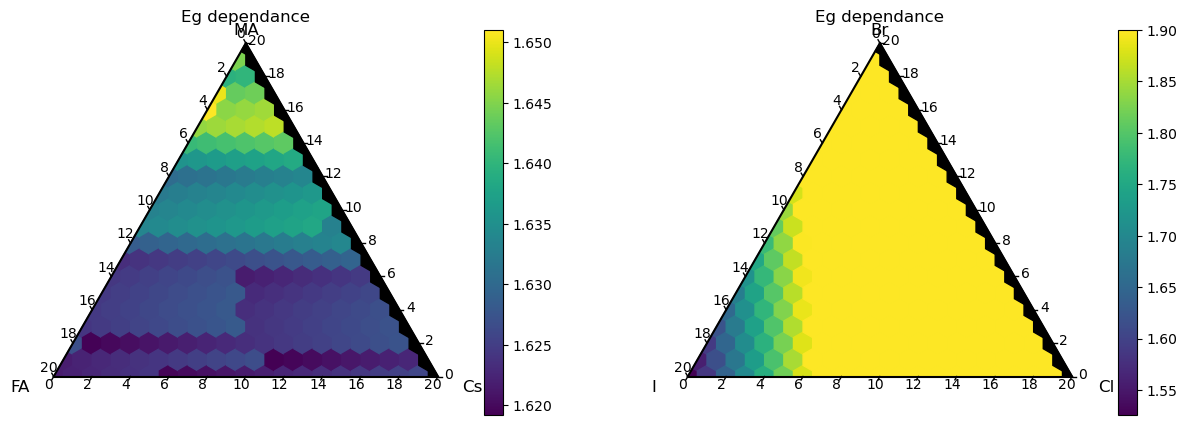

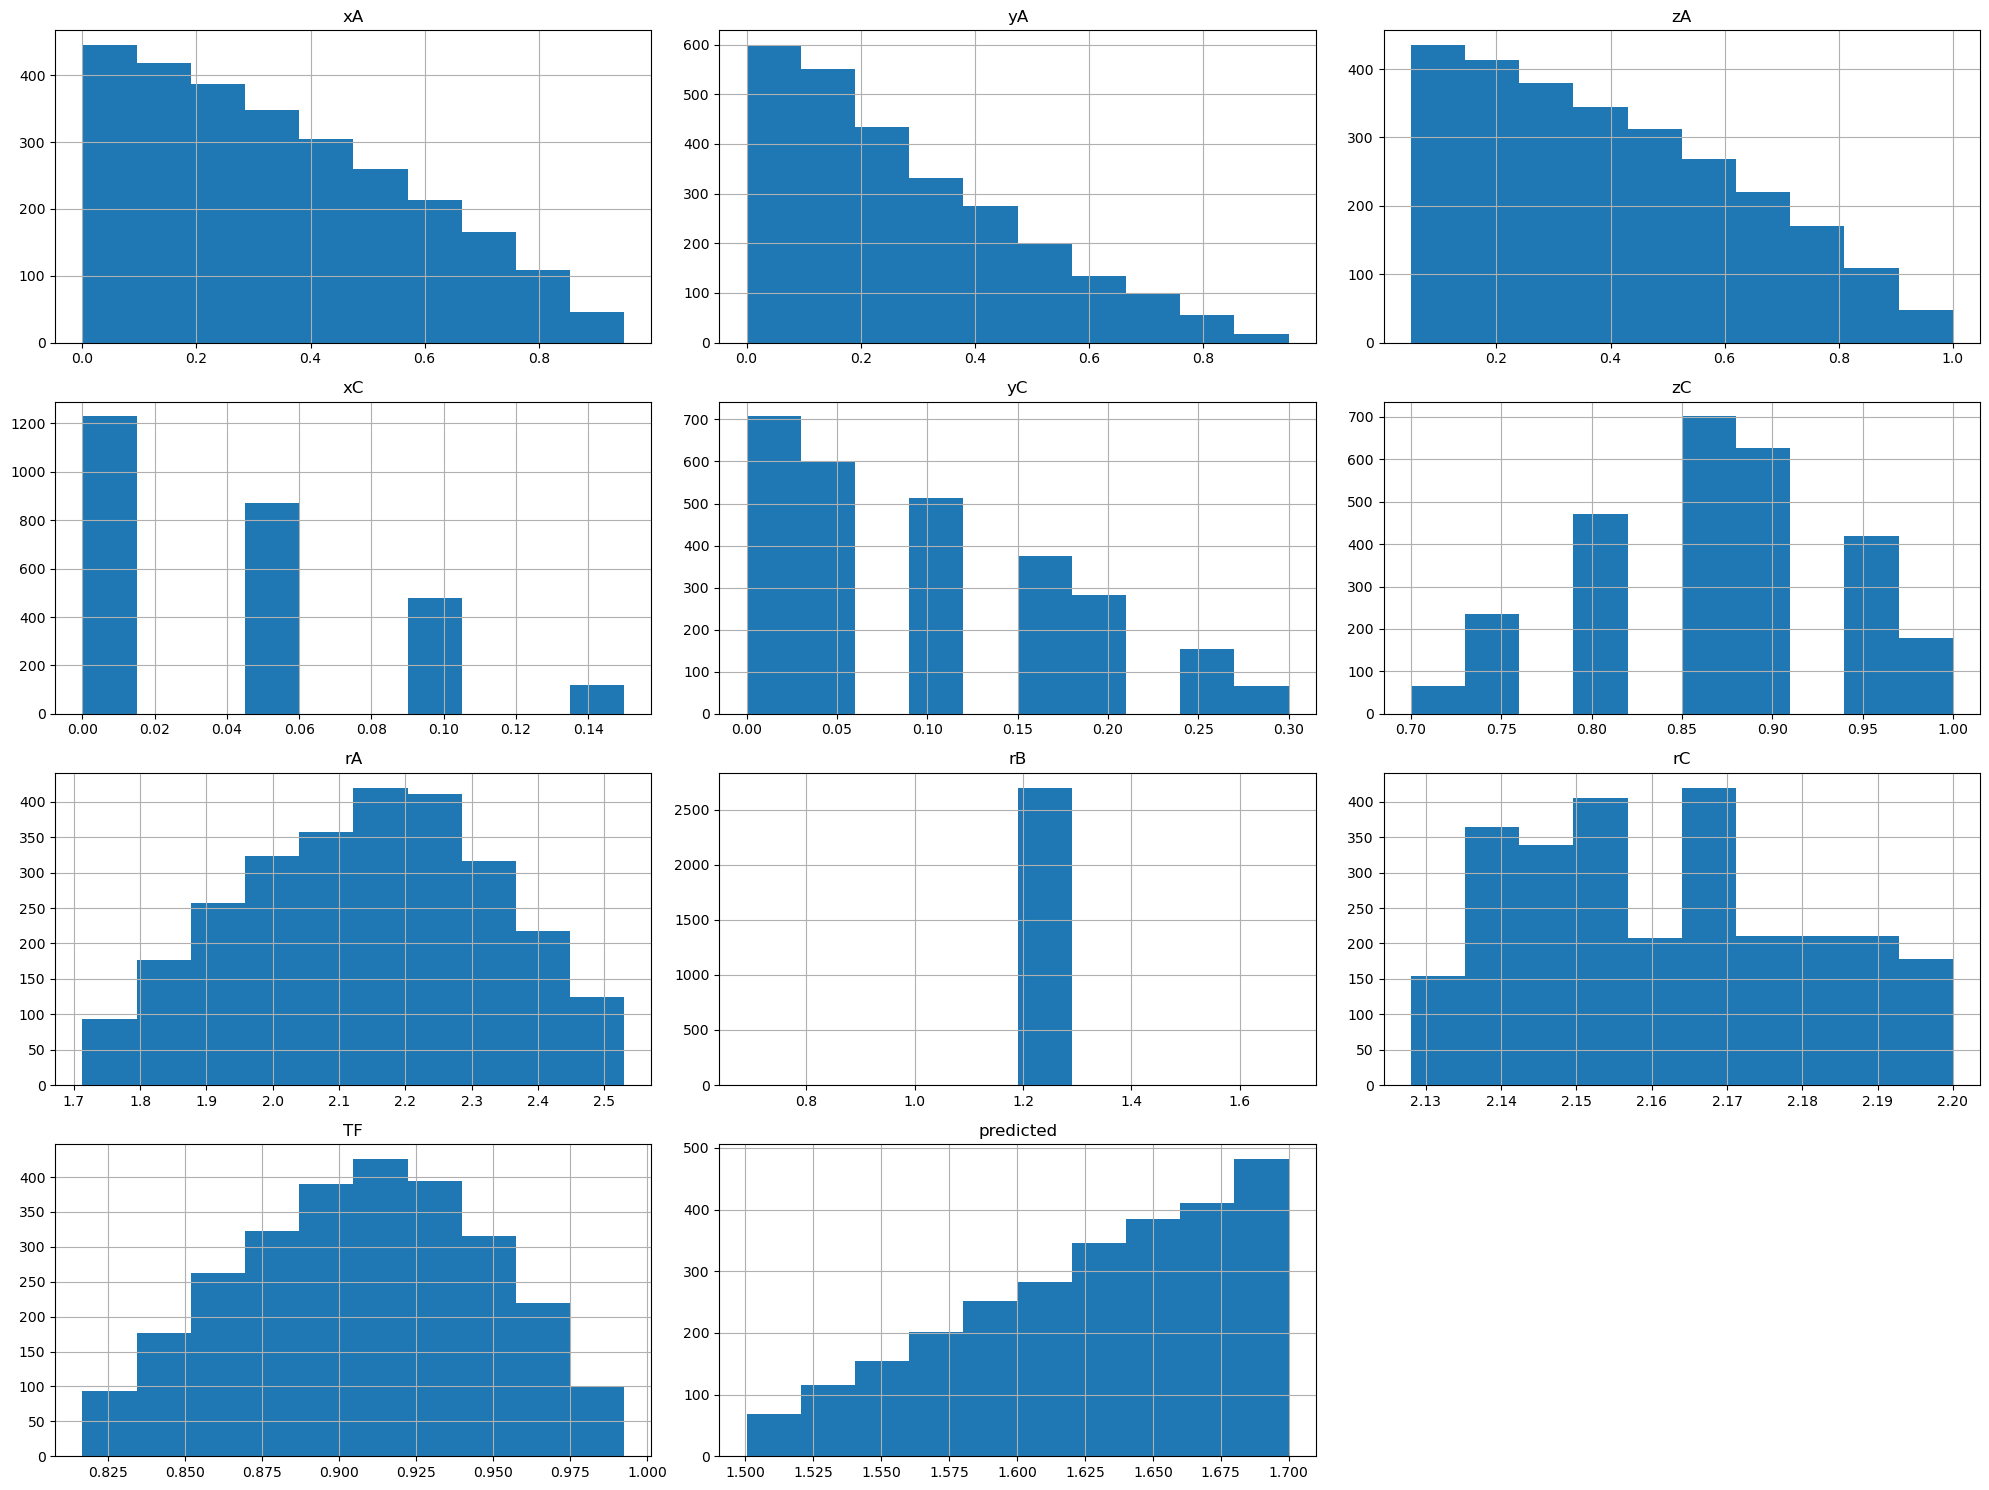

In [6]:
for name, model in models:

    model_dir = os.path.join(output_dir, name.replace(' ', '_'))
    pred_dir = os.path.join(model_dir, "prediction")
    if not os.path.exists(pred_dir):
        os.makedirs(pred_dir)

    if name == "Random Forest Regression1":
        X = X_b[["zC", "rC","TF"]]
    else:
        X = X_b

    model = joblib.load(os.path.join(model_dir, "model.joblib"))
    ###predict
    y_pred = model.predict(X)
    df["predicted"]=np.nan
    df["predicted"]=y_pred

    ##plots
    fig, ax = plt.subplots(1,2, figsize=(15, 5))
    sns.scatterplot(data=df, x="rA", y="predicted", hue="rC", ax=ax[0])
    #ax[0].plot(df["rA"], df["predicted"], ".", c=df["rC"])
    ax[0].axhline(min_Eg, linestyle="--")
    ax[0].axhline(max_Eg, linestyle="--")
    ax[0].set_xlabel("rA")
    ax[0].set_ylabel("Eg")
    sns.scatterplot(data=df, x="rC", y="predicted", hue="rA", ax=ax[1])
    ax[1].axhline(min_Eg, linestyle="--")
    ax[1].axhline(max_Eg, linestyle="--")
    #ax[1].plot(df["rC"], df["predicted"], ".")
    ax[1].set_xlabel("rC")
    ax[1].set_ylabel("Eg")
    plt.suptitle(name)
    plt.savefig(os.path.join(pred_dir, "r_vs_Eg_Sona.png"))


    df_rc = df.groupby(["xC", "yC", "zC"]).agg({'rC': ['mean', 'std'],'rA': ['mean', 'std'],'xA': ['mean', 'std'], 'predicted': ['mean', 'std']}).reset_index()
    df_rc.columns=["xC", "yC", "zC", "rC_mean", "rC_std", "rA_mean", "rA_std", "xA_mean", "xA_std","Eg_mean", "Eg_std"]
    fig, ax = plt.subplots(1,4, figsize=(15,3), sharey=True)
    df_rc["rC_mean"].hist(ax=ax[0])
    df_rc["rA_mean"].hist(ax=ax[1])
    df_rc["xA_mean"].hist(ax=ax[2])
    df_rc["Eg_mean"].hist(ax=ax[3])
    ax[0].set_xlabel("rC_mean")
    ax[1].set_xlabel("rA_mean")
    ax[2].set_xlabel("xA_mean")
    ax[3].set_xlabel("Eg_mean")
    ax[0].set_ylabel("count")
    fig, ax = plt.subplots(1,4, figsize=(15,3), sharey=True)
    df_rc["rC_std"].hist(ax=ax[0])
    df_rc["rA_std"].hist(ax=ax[1])
    df_rc["xA_std"].hist(ax=ax[2])
    df_rc["Eg_std"].hist(ax=ax[3])
    ax[0].set_xlabel("rC_std")
    ax[1].set_xlabel("rA_std")
    ax[2].set_xlabel("xA_std")
    ax[3].set_xlabel("Eg_std")
    ax[0].set_ylabel("count")
    plt.savefig(os.path.join(pred_dir, "Eg_variation_Sona.png"))

    #std of Eg is small, rA changes a lot, but affects by little the Eg value

    df_selected=df[(df["predicted"]<max_Eg)&(df["predicted"]>min_Eg)]

    fig, ax = plt.subplots(1,2, figsize = (15, 5))
    data = generate_heatmap_data_for_r(scale, "C", dtf=df)
    figure, tax = ternary.figure(ax = ax[1], scale=scale)
    tax.heatmap(data, style="hexagonal", use_rgba=False, vmax=1.9)
    tax.boundary()
    tax.right_corner_label("Cl", fontsize=fontsize, offset=offset)
    tax.top_corner_label("Br", fontsize=fontsize, offset=offset)
    tax.left_corner_label("I", fontsize=fontsize, offset=offset)
    tax.set_title("Eg dependance")
    tax.ticks(axis='lbr', linewidth=1, multiple=2)
    tax.get_axes().axis('off')
    tax.clear_matplotlib_ticks()
    data = generate_heatmap_data_for_r(scale, "A", dtf=df_selected)
    figure, tax = ternary.figure(ax = ax[0], scale=scale)
    tax.heatmap(data, style="hexagonal", use_rgba=False)
    tax.boundary()
    tax.right_corner_label("Cs", fontsize=fontsize, offset=offset)
    tax.top_corner_label("MA", fontsize=fontsize, offset=offset)
    tax.left_corner_label("FA", fontsize=fontsize, offset=offset)
    tax.set_title("Eg dependance")
    tax.ticks(axis='lbr', linewidth=1, multiple=2)
    tax.get_axes().axis('off')
    tax.clear_matplotlib_ticks()
    plt.savefig(os.path.join(pred_dir, "Eg_vs_xyz_Sona.png"))

    df_selected.hist(figsize=(20, 15))
    plt.tight_layout()
    plt.savefig(os.path.join(pred_dir, "selected_cases_var_dist_Sona.png"))


    df_selected[df_selected["TF"]>min_TF].sort_values(["xA", "yA", "zA", "xC", "yC", "zC"], ascending=True).to_csv(
        os.path.join(pred_dir, "final_selection_"+str(min_Eg)+"_"+str(max_Eg)+"_"+str(min_TF)+".csv"))


In [7]:
df[(df["xC"]==0)&(df["yC"]==0.4)&(df["rC"]>2.08)&(df["rC"]<2.11)]

,xA,yA,zA,xC,yC,zC,rA,rB,rC,TF,predicted
8,0.00,0.00,1.00,0.0,0.4,0.6,2.5300,1.19,2.104,0.994758,1.744367
218,0.00,0.05,0.95,0.0,0.4,0.6,2.5115,1.19,2.104,0.990787,1.749526
428,0.00,0.10,0.90,0.0,0.4,0.6,2.4930,1.19,2.104,0.986815,1.754685
638,0.00,0.15,0.85,0.0,0.4,0.6,2.4745,1.19,2.104,0.982844,1.759843
848,0.00,0.20,0.80,0.0,0.4,0.6,2.4560,1.19,2.104,0.978873,1.765002
...,...,...,...,...,...,...,...,...,...,...,...
43058,0.85,0.05,0.10,0.0,0.4,0.6,1.7805,1.19,2.104,0.833867,1.757341
43268,0.85,0.10,0.05,0.0,0.4,0.6,1.7620,1.19,2.104,0.829895,1.762500
43478,0.90,0.00,0.10,0.0,0.4,0.6,1.7560,1.19,2.104,0.828607,1.752642
43688,0.90,0.05,0.05,0.0,0.4,0.6,1.7375,1.19,2.104,0.824636,1.757801
